#### Agent_4: LLM as a Agent

In [12]:
# import os
# # import getpass
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# if not os.environ.get("LANGSMITH_API_KEY"):
#     os.environ["LANGSMITH_API_KEY"] = getpass.getpass()

In [1]:
from typing import TypedDict,List
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
#from dotenv import load_dotenv  Saving API KEYS
#load_dotenv()

In [2]:
# AWS Bedrock LLM Setup
# ---------------------------
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=500)


In [3]:
llm.invoke("Hi").content

'Hello! How can I assist you today?'

In [4]:
class AgentState(TypedDict):
    messages:List[HumanMessage]

In [5]:
def process(state:AgentState)->AgentState:
    """LLM as a Agent"""
    response =llm.invoke(state['messages'])
    print(f'AI Message:{response.content}')
    state['messages']=response.content
    return state


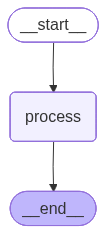

In [6]:
graph =StateGraph(AgentState)

graph.add_node('process',process)

graph.add_edge(START,'process')

graph.add_edge('process',END)

graph.compile()

In [7]:
app=graph.compile()

In [8]:
user_input =input("Your Message:")
while user_input!='exit':
    response=app.invoke({'messages': [HumanMessage(content=user_input)]})
    print(response)
    user_input=input("Your Message:")

Your Message: Hi


AI Message:Hello! How can I help you today?
{'messages': 'Hello! How can I help you today?'}


Your Message: I am good how about you?


AI Message:As an AI chatbot, I don't possess personal feelings or emotions, so the concept of "being good" doesn't apply to me in the same way it does to humans. However, I'm functioning optimally and ready to assist you with any queries or tasks you have in mind. How can I help you today?
{'messages': 'As an AI chatbot, I don\'t possess personal feelings or emotions, so the concept of "being good" doesn\'t apply to me in the same way it does to humans. However, I\'m functioning optimally and ready to assist you with any queries or tasks you have in mind. How can I help you today?'}


Your Message: Great to learn that.


AI Message:Is there anything else I can help you with?
{'messages': 'Is there anything else I can help you with?'}


Your Message: exit


In [11]:
user_input =input("Your Message:")
while user_input!='exit':
    response=app.invoke({'messages': [HumanMessage(content=user_input)]})
    print(response)
    user_input=input("Your Message:")

Your Message: Hi


AI Message:Hello! How can I help you today?
{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={})]}


Your Message: I want to learn quantum theory


AI Message:Sure! Quantum theory is a fundamental concept in physics that describes the behavior of particles at the microscopic level, such as atoms and subatomic particles. It's a complex and fascinating theory that has revolutionized our understanding of the physical world. Here's a basic overview to get you started:

**Principles of Quantum Theory:**
1. **Wave-Particle Duality:** Quantum theory suggests that particles can exhibit both wave-like and particle-like properties. This duality is described by the wavefunction, which provides the probability of finding a particle at a particular location.
2. **Superposition:** One of the key concepts is superposition, which means that a particle can exist in multiple states simultaneously. For example, an electron can be in multiple energy levels around a nucleus at the same time.
3. **Uncertainty Principle:** Werner Heisenberg's Uncertainty Principle states that there are inherent limits to how precisely we can know both the position and m

Your Message: exit
